<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 4, Forecasting Jerárquico**

Instalamos lo necesario

In [ ]:
!pip install -q datasetsforecast statsforecast neuralforecast hierarchicalforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 306.7/306.7 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 MB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Importamos las librerias necesarias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasetsforecast.hierarchical import HierarchicalData
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR

Libreria de reconciliacion jerarquica: es la que de verdad usa S_df y tags en vez de sumar series "a mano". Con esto el mismo codigo funciona para cualquier jerarquia, no solo para "total + 4 hijos".

In [ ]:
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace

Descargamos el dataset

In [ ]:
Y_df, S_df, tags = HierarchicalData.load(
    directory="data",
    group="TourismSmall"
)

100%|██████████| 1.30M/1.30M [00:00<00:00, 13.0MiB/s]
100%|██████████| 335k/335k [00:00<00:00, 4.28MiB/s]
100%|██████████| 968k/968k [00:00<00:00, 9.24MiB/s]


datasetsforecast devuelve S_df con "unique_id" como INDICE del DataFrame. hierarchicalforecast en cambio necesita que "unique_id" sea una columna normal, asi que lo convertimos aca (una sola vez, para todo el notebook).

In [ ]:
if S_df.index.name == "unique_id" or "unique_id" not in S_df.columns:
    S_df = S_df.reset_index().rename(columns={S_df.index.name or "index": "unique_id"})

In [ ]:
print(Y_df.head())
print("Numero de series:", Y_df["unique_id"].nunique())

  unique_id          ds      y
0     total  1998-03-31  84503
1     total  1998-06-30  65312
2     total  1998-09-30  72753
3     total  1998-12-31  70880
4     total  1999-03-31  86893
Numero de series: 89


S_df: matriz de sumacion (define como se agregan las series hijas en las series padre). tags: diccionario con los niveles de la jerarquia. Estos dos objetos son la razon de ser de este dataset y los vamos a usar recien en la Parte C para reconciliar de forma correcta.

**Exploración rápida**

This series contains several components:

One component named "Total",

One component per region ("NSW", "VIC", etc)

One component per tourism reason ("Hol" for holiday, "Bus" for business, etc)

One component per (region, reason) pair (named "NSW - hol", "NSW - bus", etc)

One component per (region, reason, <city>) tuple, where <city> is either "city" or "noncity". So these are components named "NSW - hol - city", "NSW - hol - noncity", "NSW - bus - city", etc.

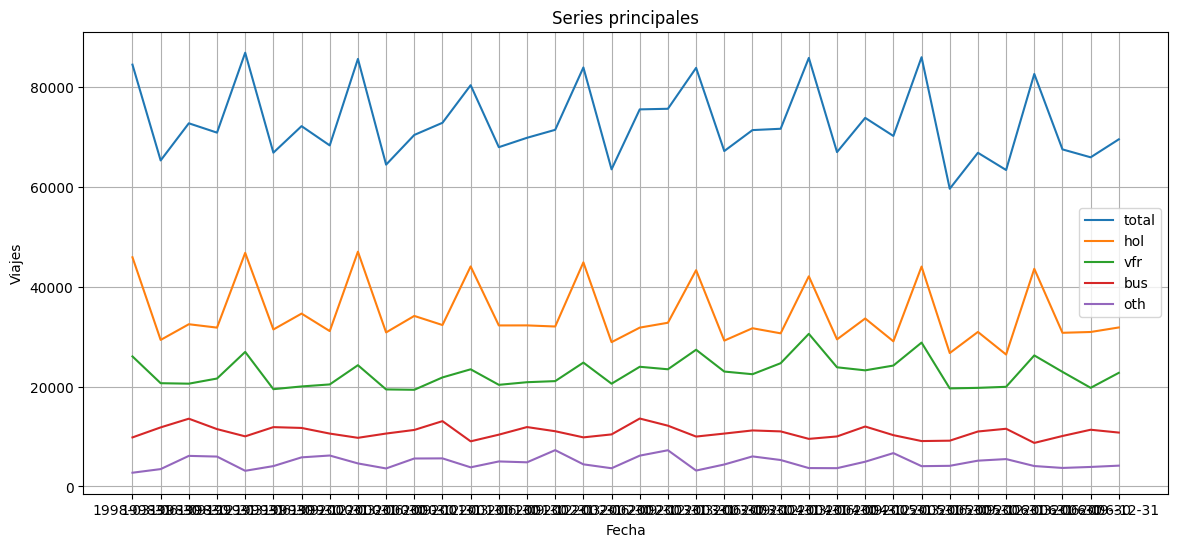

In [ ]:
series = ["total", "hol", "vfr", "bus", "oth"]

plt.figure(figsize=(14, 6))
for s in series:
    temp = Y_df[Y_df["unique_id"] == s]
    plt.plot(temp["ds"], temp["y"], label=s)
plt.title("Series principales")
plt.xlabel("Fecha")
plt.ylabel("Viajes")
plt.legend()
plt.grid(True)
plt.show()

Verificamos la coherencia histórica (Total = Hol+VFR+Bus+Oth)

In [ ]:
total = Y_df[Y_df.unique_id == "total"].copy()
hol   = Y_df[Y_df.unique_id == "hol"].copy()
vfr   = Y_df[Y_df.unique_id == "vfr"].copy()
bus   = Y_df[Y_df.unique_id == "bus"].copy()
oth   = Y_df[Y_df.unique_id == "oth"].copy()

In [ ]:
comparacion = pd.DataFrame({
    "Fecha": total["ds"].values,
    "Total": total["y"].values,
    "Hol+VFR+Bus+Oth": hol["y"].values + vfr["y"].values + bus["y"].values + oth["y"].values
})

In [ ]:
comparacion["Error"] = comparacion["Total"] - comparacion["Hol+VFR+Bus+Oth"]
print(comparacion["Error"].describe())

count    36.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Error, dtype: float64


Los datos historicos son coherentes. El problema aparece cuando entrenamos un modelo independiente por serie: cada modelo "no sabe" que existe una jerarquia, asi que nada garantiza que los forecasts sigan sumando.

### **A) Modelo independiente por serie (AutoARIMA)**

Horizonte de pronóstico

In [ ]:
h = 8

Definimos función que separa cada serie en train/test dejando los ultimos h periodos como prueba. group_keys=False evita que pandas duplique el indice de agrupacion (warning en versiones recientes).

In [ ]:
def split_train_test(df, h):
    train = df.groupby("unique_id", group_keys=False).apply(lambda x: x.iloc[:-h])
    test = df.groupby("unique_id", group_keys=False).apply(lambda x: x.iloc[-h:])
    return train.reset_index(drop=True), test.reset_index(drop=True)

In [ ]:
train, test = split_train_test(Y_df, h)
train["ds"] = pd.to_datetime(train["ds"])
test["ds"] = pd.to_datetime(test["ds"])

/tmp/ipykernel_797/3841830452.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train = df.groupby("unique_id", group_keys=False).apply(lambda x: x.iloc[:-h])
/tmp/ipykernel_797/3841830452.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test = df.groupby("unique_id", group_keys=False).apply(lambda x: x.iloc[-h:])


In [ ]:
print("Entrenamiento:", train.shape)
print("Prueba:", test.shape)

Entrenamiento: (2492, 3)
Prueba: (712, 3)


In [ ]:
sf = StatsForecast(
    models=[AutoARIMA()],
    freq="Q",
    n_jobs=-1)

Usamos sf.forecast(..., fitted=True) en vez de fit()+predict(): asi podemos despues pedir los valores ajustados in-sample con forecast_fitted_values(), que son necesarios para MinTrace en la Parte C.

In [ ]:
forecast = sf.forecast(df=train, h=h, fitted=True)
sf_fitted = sf.forecast_fitted_values()  # unique_id, ds, y, AutoARIMA (in-sample)

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


In [ ]:
print(forecast.head())

  unique_id         ds     AutoARIMA
0       bus 2005-03-31  11018.821289
1       bus 2005-06-30  11018.821289
2       bus 2005-09-30  11018.821289
3       bus 2005-12-31  11018.821289
4       bus 2006-03-31  11018.821289


Graficamos la serie total

In [ ]:
serie = "total"
hist = train[train["unique_id"] == serie].copy()
real = test[test["unique_id"] == serie].copy()
pred = forecast[forecast["unique_id"] == serie].copy()

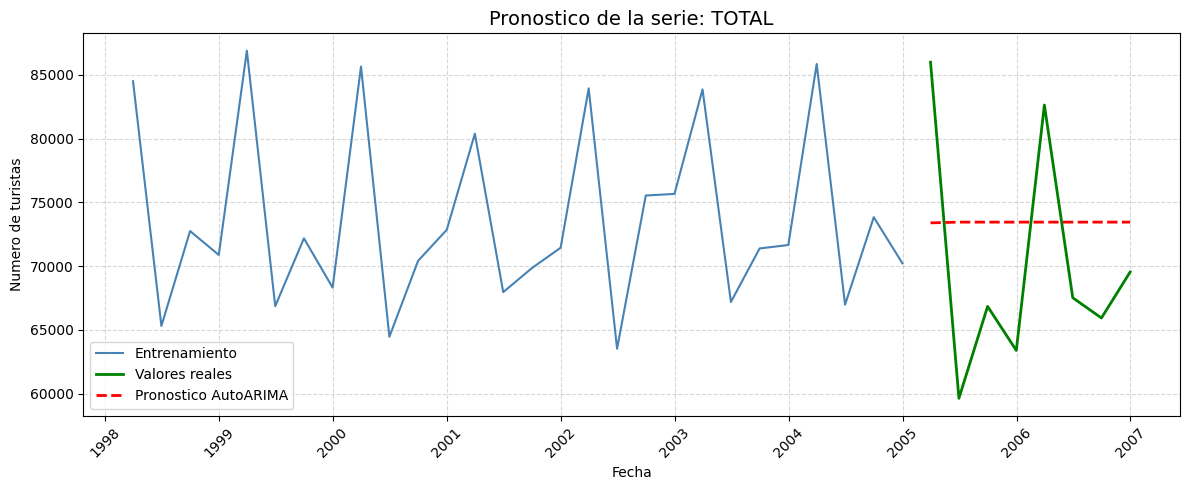

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(hist["ds"], hist["y"], label="Entrenamiento", color="steelblue")
plt.plot(real["ds"], real["y"], label="Valores reales", color="green", linewidth=2)
plt.plot(pred["ds"], pred["AutoARIMA"], label="Pronostico AutoARIMA", color="red", linewidth=2, linestyle="--")
plt.title(f"Pronostico de la serie: {serie.upper()}", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Numero de turistas")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Graficamos todas las series principales

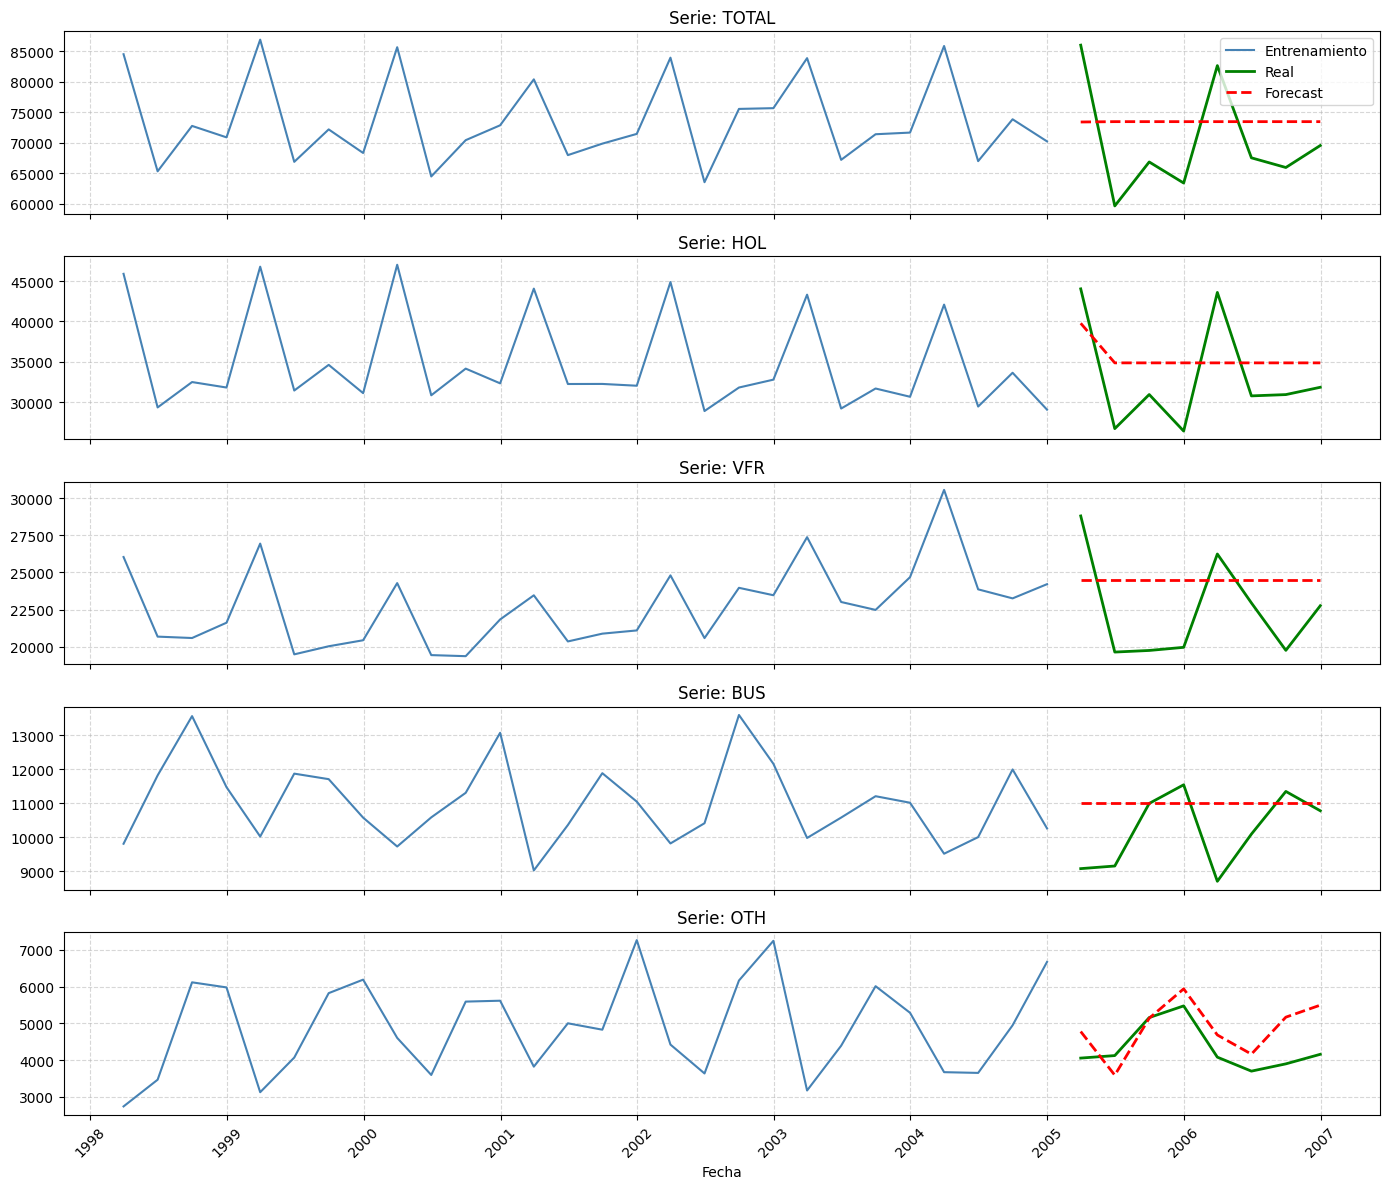

In [ ]:
fig, axes = plt.subplots(len(series), 1, figsize=(14, 12), sharex=True)
for i, s in enumerate(series):
    hist = train[train["unique_id"] == s].copy()
    real = test[test["unique_id"] == s].copy()
    pred = forecast[forecast["unique_id"] == s].copy()
    axes[i].plot(hist["ds"], hist["y"], label="Entrenamiento", color="steelblue")
    axes[i].plot(real["ds"], real["y"], label="Real", color="green", linewidth=2)
    axes[i].plot(pred["ds"], pred["AutoARIMA"], label="Forecast", color="red", linewidth=2, linestyle="--")
    axes[i].set_title(f"Serie: {s.upper()}")
    axes[i].grid(True, linestyle="--", alpha=0.5)
    if i == 0:
        axes[i].legend()
axes[-1].set_xlabel("Fecha")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Verificamos si los pronósticos de AutoARIMA son coherentes

In [ ]:
f_total = forecast[forecast.unique_id == "total"].sort_values("ds")
f_hol   = forecast[forecast.unique_id == "hol"].sort_values("ds")
f_vfr   = forecast[forecast.unique_id == "vfr"].sort_values("ds")
f_bus   = forecast[forecast.unique_id == "bus"].sort_values("ds")
f_oth   = forecast[forecast.unique_id == "oth"].sort_values("ds")

In [ ]:
comparacion = pd.DataFrame({
    "Fecha": f_total["ds"].values,
    "Forecast_Total": f_total["AutoARIMA"].values,
    "Suma_Componentes": (f_hol["AutoARIMA"].values + f_vfr["AutoARIMA"].values +
                          f_bus["AutoARIMA"].values + f_oth["AutoARIMA"].values)
})

In [ ]:
comparacion["Diferencia"] = comparacion["Forecast_Total"] - comparacion["Suma_Componentes"]
print(comparacion)

       Fecha  Forecast_Total  Suma_Componentes   Diferencia
0 2005-03-31    73395.046875      80083.515625 -6688.468750
1 2005-06-30    73453.328125      73988.062500  -534.734375
2 2005-09-30    73453.328125      75536.500000 -2083.171875
3 2005-12-31    73453.328125      76335.453125 -2882.125000
4 2006-03-31    73453.328125      75081.578125 -1628.250000
5 2006-06-30    73453.328125      74559.750000 -1106.421875
6 2006-09-30    73453.328125      75565.695312 -2112.367188
7 2006-12-31    73453.328125      75892.484375 -2439.156250


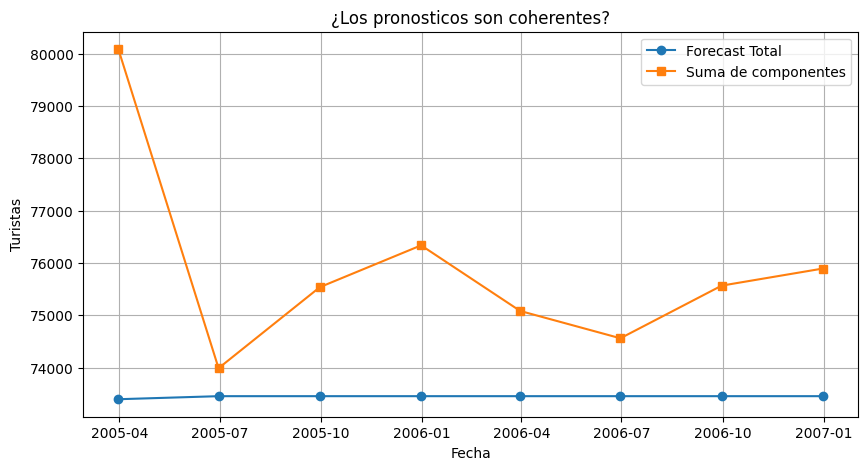

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(comparacion["Fecha"], comparacion["Forecast_Total"], marker="o", label="Forecast Total")
plt.plot(comparacion["Fecha"], comparacion["Suma_Componentes"], marker="s", label="Suma de componentes")
plt.title("¿Los pronosticos son coherentes?")
plt.xlabel("Fecha")
plt.ylabel("Turistas")
plt.legend()
plt.grid(True)
plt.show()

**Bottom-up**

Esto solo funciona porque conocemos a mano que "total" tiene exactamente estos 4 hijos. En la Parte C hacemos lo mismo pero con la libreria, usando S_df/tags, que generaliza a cualquier jerarquia.

In [ ]:
forecast_total_original = f_total["AutoARIMA"].values
forecast_total_bottomup = (f_hol["AutoARIMA"].values + f_vfr["AutoARIMA"].values +
                            f_bus["AutoARIMA"].values + f_oth["AutoARIMA"].values)

In [ ]:
resultado_bu = pd.DataFrame({
    "Fecha": f_total["ds"].values,
    "Forecast Tradicional": forecast_total_original,
    "Forecast Bottom-Up": forecast_total_bottomup
})
print(resultado_bu)

       Fecha  Forecast Tradicional  Forecast Bottom-Up
0 2005-03-31          73395.046875        80083.515625
1 2005-06-30          73453.328125        73988.062500
2 2005-09-30          73453.328125        75536.500000
3 2005-12-31          73453.328125        76335.453125
4 2006-03-31          73453.328125        75081.578125
5 2006-06-30          73453.328125        74559.750000
6 2006-09-30          73453.328125        75565.695312
7 2006-12-31          73453.328125        75892.484375


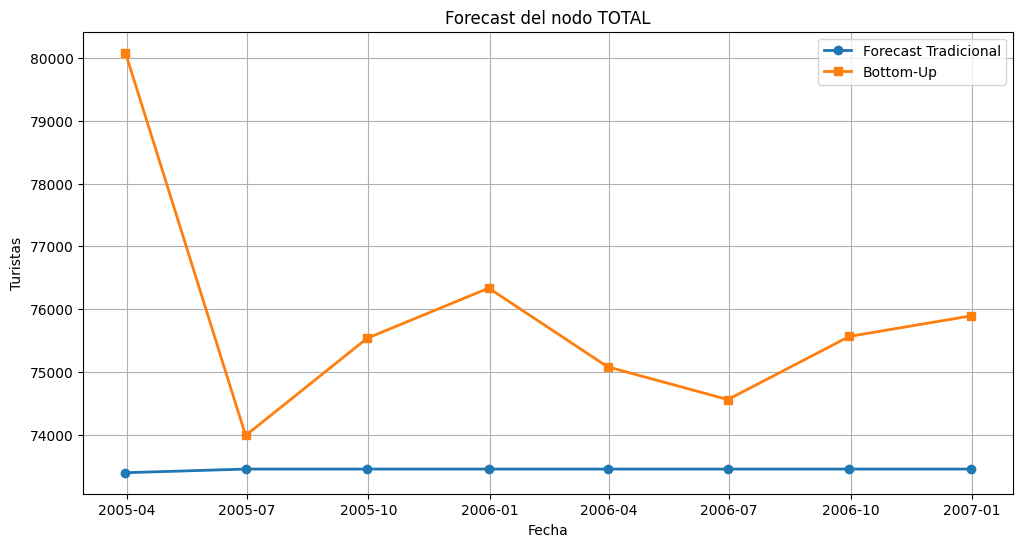

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(resultado_bu["Fecha"], resultado_bu["Forecast Tradicional"], marker="o", linewidth=2, label="Forecast Tradicional")
plt.plot(resultado_bu["Fecha"], resultado_bu["Forecast Bottom-Up"], marker="s", linewidth=2, label="Bottom-Up")
plt.title("Forecast del nodo TOTAL")
plt.xlabel("Fecha")
plt.ylabel("Turistas")
plt.grid(True)
plt.legend()
plt.show()

Forecast tradicional: Total = modelo independiente (incoherente)


Bottom-Up:             Total = Hol + VFR + Bus + Oth (coherente por construccion)

### **B) Forecasting Jerárquico con DeepAR**

In [ ]:
model = DeepAR(
    h=h,
    input_size=16,
    max_steps=300,
    learning_rate=0.001,
    scaler_type="robust",
    random_seed=42
)

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [ ]:
nf = NeuralForecast(models=[model], freq="Q")
nf.fit(df=train)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type             | Params | Mode 
-----------------------------------------------------------------
0 | loss                | DistributionLoss | 5      | train
1 | valid_loss          | MAE              | 0      | train
2 | hist_cat_embeddings | ModuleList       | 0      | train
3 | futr_cat_embeddings | ModuleList       | 0      | train
4 | stat_cat_embeddings | ModuleList       | 0      | train
5 | padder_train        | ConstantPad1d    | 0      | train
6 | scaler              | TemporalNorm     | 0      | train
7 | hist_encoder        | LSTM             | 199 K  | train
8 | decoder             | MLP              | 387    | train
-----------------------------------------------------------------
199 K     Trainable params
5         Non-trainable params
1

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=300` reached.


In [ ]:
deep_forecast = nf.predict()
print(deep_forecast.head())

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:462: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

  unique_id         ds        DeepAR  DeepAR-median  DeepAR-lo-90  \
0       bus 2005-03-31  10136.177734   10163.207031   8967.085938   
1       bus 2005-06-30  10485.885742   10287.187500   8291.557617   
2       bus 2005-09-30  11311.364258   11235.490234   9583.891602   
3       bus 2005-12-31  10909.802734   11052.988281   9088.704102   
4       bus 2006-03-31  10141.889648   10265.598633   8779.666992   

   DeepAR-lo-80  DeepAR-hi-80  DeepAR-hi-90  
0   9303.155273  11279.707031  11915.278320  
1   9049.106445  11433.467773  11702.370117  
2   9992.798828  12853.262695  13319.639648  
3   9757.012695  12060.396484  12342.528320  
4   9209.874023  11098.166016  11439.471680  


Valores ajustados in-sample: los necesitamos para MinTrace en la Parte C. step_size=h (en vez de 1) evita ventanas superpuestas: con step_size=1 cada fecha queda pronosticada por varias ventanas distintas y terminas con (unique_id, ds) duplicados, lo cual rompe la reconciliacion despues.

In [ ]:
deep_fitted = nf.predict_insample(step_size=h)

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:406: FutureWarning: 'Q' is deprecated and will be re

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Aun asi, por las dudas (algunas versiones dejan el ultimo cutoff parcial solapado), nos quedamos con una sola fila por (unique_id, ds).

In [ ]:
deep_fitted = deep_fitted.drop_duplicates(subset=["unique_id", "ds"], keep="last")

Graficamos DeepAR vs real, serie "total"

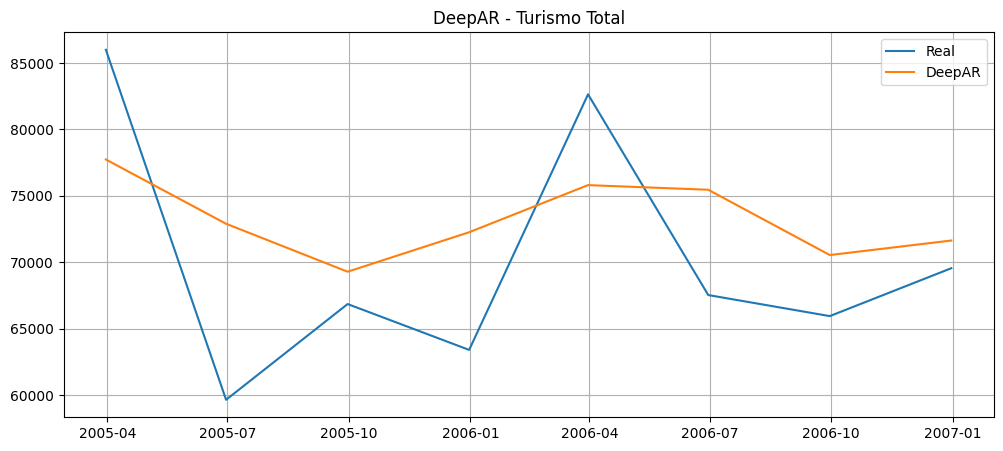

In [ ]:
serie = "total"
real = test[test.unique_id == serie]
pred = deep_forecast[deep_forecast.unique_id == serie]

plt.figure(figsize=(12, 5))
plt.plot(real.ds, real.y, label="Real")
plt.plot(pred.ds, pred["DeepAR-median"], label="DeepAR")
plt.title("DeepAR - Turismo Total")
plt.legend()
plt.grid()
plt.show()

Coherencia jerarquica de DeepAR

In [ ]:
f_total = deep_forecast[deep_forecast.unique_id == "total"]
f_hol   = deep_forecast[deep_forecast.unique_id == "hol"]
f_vfr   = deep_forecast[deep_forecast.unique_id == "vfr"]
f_bus   = deep_forecast[deep_forecast.unique_id == "bus"]
f_oth   = deep_forecast[deep_forecast.unique_id == "oth"]

In [ ]:
comparacion = pd.DataFrame({
    "Fecha": f_total.ds.values,
    "DeepAR Total": f_total["DeepAR-median"].values,
    "Suma componentes": (f_hol["DeepAR-median"].values + f_vfr["DeepAR-median"].values +
                          f_bus["DeepAR-median"].values + f_oth["DeepAR-median"].values)
})
comparacion["Error"] = comparacion["DeepAR Total"] - comparacion["Suma componentes"]
print(comparacion)

       Fecha  DeepAR Total  Suma componentes        Error
0 2005-03-31  77730.281250      75039.460938  2690.820312
1 2005-06-30  72890.234375      73607.796875  -717.562500
2 2005-09-30  69280.078125      68717.984375   562.093750
3 2005-12-31  72252.953125      70660.078125  1592.875000
4 2006-03-31  75800.921875      74751.984375  1048.937500
5 2006-06-30  75451.953125      72707.859375  2744.093750
6 2006-09-30  70535.562500      69792.789062   742.773438
7 2006-12-31  71628.687500      69367.968750  2260.718750


**Bottom-Up manual sobre DeepAR**

In [ ]:
deep_bottomup_total = (f_hol["DeepAR-median"].values + f_vfr["DeepAR-median"].values +
                        f_bus["DeepAR-median"].values + f_oth["DeepAR-median"].values)

In [ ]:
resultado = pd.DataFrame({
    "Fecha": f_total.ds.values,
    "DeepAR original": f_total["DeepAR-median"].values,
    "DeepAR Bottom-Up": deep_bottomup_total
})
print(resultado)

       Fecha  DeepAR original  DeepAR Bottom-Up
0 2005-03-31     77730.281250      75039.460938
1 2005-06-30     72890.234375      73607.796875
2 2005-09-30     69280.078125      68717.984375
3 2005-12-31     72252.953125      70660.078125
4 2006-03-31     75800.921875      74751.984375
5 2006-06-30     75451.953125      72707.859375
6 2006-09-30     70535.562500      69792.789062
7 2006-12-31     71628.687500      69367.968750


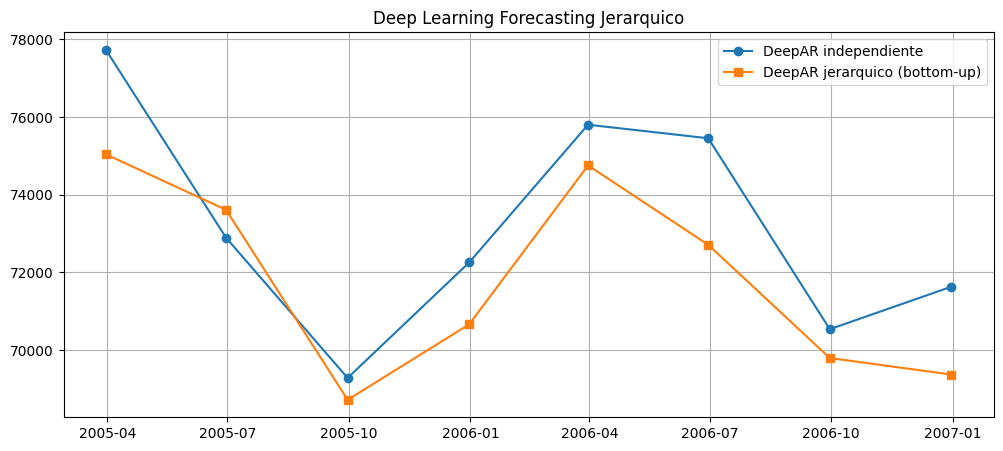

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(resultado.Fecha, resultado["DeepAR original"], marker="o", label="DeepAR independiente")
plt.plot(resultado.Fecha, resultado["DeepAR Bottom-Up"], marker="s", label="DeepAR jerarquico (bottom-up)")
plt.title("Deep Learning Forecasting Jerarquico")
plt.legend()
plt.grid()
plt.show()

### **C) Reconciliacion formal con hierarchicalforecast (Bottom-Up y MinT)**

¿Que es MinT (Minimum Trace / MinTrace)?

Bottom-Up siempre confia 100% en los forecasts de las hojas y descarta el forecast del nodo padre, aunque este haya sido mejor. MinT en cambio combina los forecasts de todos los niveles de la jerarquia, ponderando cada uno segun que tan confiable fue historicamente (usa la covarianza de los errores in-sample). El resultado es coherente (las series vuelven a sumar correctamente) y en general mas preciso que Bottom-Up puro.

In [ ]:
hrec = HierarchicalReconciliation(reconcilers=[
    BottomUp(),
    MinTrace(method="ols"),          # MinT simplificado (asume errores no correlacionados)
    MinTrace(method="mint_shrink"),  # MinT completo, con estimador de covarianza shrinkage
])

#### **C.1) Reconciliar AutoARIMA**

In [ ]:
# Y_hat_df: forecasts base (unique_id, ds, AutoARIMA)
# Y_df:     valores in-sample reales + ajustados (unique_id, ds, y, AutoARIMA) -> para estimar residuos
reconciled_arima = hrec.reconcile(
    Y_hat_df=forecast,
    Y_df=sf_fitted,
    S_df=S_df,   # en versiones recientes de hierarchicalforecast el parametro se llama S_df, no S
    tags=tags
)
print(reconciled_arima.head())

  unique_id         ds     AutoARIMA  AutoARIMA/BottomUp  \
0     total 2005-03-31  73395.046875        78652.999443   
1     total 2005-06-30  73453.328125        73530.942043   
2     total 2005-09-30  73453.328125        74445.113144   
3     total 2005-12-31  73453.328125        73993.890980   
4     total 2006-03-31  73453.328125        74474.260475   

   AutoARIMA/MinTrace_method-ols  AutoARIMA/MinTrace_method-mint_shrink  
0                   74861.460604                           79295.807923  
1                   73572.404498                           74026.916655  
2                   73905.473103                           73080.244863  
3                   74040.326395                           72314.539583  
4                   73834.320809                           76550.249040  


#### **C.1) Reconciliar DeepAR**

DeepAR devuelve columnas de cuantiles (DeepAR-median, DeepAR-lo-x, etc.). Para reconciliar solo necesitamos el forecast puntual, asi que nos quedamos con la mediana y la renombramos a "DeepAR" para que Y_hat_df y Y_df tengan el mismo nombre de modelo.

In [ ]:
deep_forecast_point = (
    deep_forecast[["unique_id", "ds", "DeepAR-median"]]
    .rename(columns={"DeepAR-median": "DeepAR"})
)
deep_fitted_point = (
    deep_fitted[["unique_id", "ds", "y", "DeepAR-median"]]
    .rename(columns={"DeepAR-median": "DeepAR"})
)

reconciled_deepar = hrec.reconcile(
    Y_hat_df=deep_forecast_point,
    Y_df=deep_fitted_point,
    S_df=S_df,   # idem: S_df en vez de S
    tags=tags
)
print(reconciled_deepar.head())


  unique_id         ds        DeepAR  DeepAR/BottomUp  \
0     total 2005-03-31  77730.281250     75596.396915   
1     total 2005-06-30  72890.234375     73036.166718   
2     total 2005-09-30  69280.078125     69234.027195   
3     total 2005-12-31  72252.953125     69197.710785   
4     total 2006-03-31  75800.921875     73381.211731   

   DeepAR/MinTrace_method-ols  DeepAR/MinTrace_method-mint_shrink  
0                77149.490722                        74478.489471  
1                73017.573895                        68265.203593  
2                69176.803145                        67158.375941  
3                71848.912466                        61074.391053  
4                75510.568467                        72275.841406  


Verificar que ahora todo es coherente (para cualquier metodo)

In [ ]:
def verificar_coherencia(df, col_total, cols_hijos, nombre):
    total_vals = df[df.unique_id == "total"].sort_values("ds")[col_total].values
    suma_hijos = sum(df[df.unique_id == s].sort_values("ds")[col_total].values for s in cols_hijos)
    error = np.abs(total_vals - suma_hijos).max()
    print(f"{nombre}: error maximo de coherencia = {error:.6f}")

In [ ]:
hijos = ["hol", "vfr", "bus", "oth"]
verificar_coherencia(reconciled_arima, "AutoARIMA/BottomUp", hijos, "AutoARIMA + Bottom-Up")
verificar_coherencia(reconciled_arima, "AutoARIMA/MinTrace_method-mint_shrink", hijos, "AutoARIMA + MinT (shrink)")
verificar_coherencia(reconciled_deepar, "DeepAR/BottomUp", hijos, "DeepAR + Bottom-Up")
verificar_coherencia(reconciled_deepar, "DeepAR/MinTrace_method-mint_shrink", hijos, "DeepAR + MinT (shrink)")

AutoARIMA + Bottom-Up: error maximo de coherencia = 0.000000
AutoARIMA + MinT (shrink): error maximo de coherencia = 0.000000
DeepAR + Bottom-Up: error maximo de coherencia = 0.000000
DeepAR + MinT (shrink): error maximo de coherencia = 0.000000


Grafico final: original vs Bottom-Up vs MinT, para DeepAR

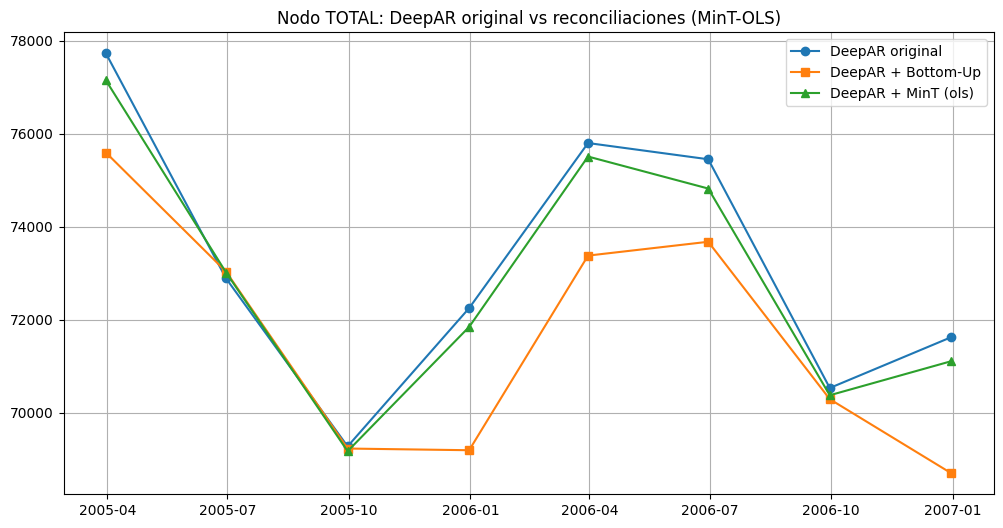

In [ ]:
f_total_ols = reconciled_deepar[reconciled_deepar.unique_id == "total"].sort_values("ds")

plt.figure(figsize=(12,6))
plt.plot(f_total_ols["ds"], f_total_ols["DeepAR"], marker="o", label="DeepAR original")
plt.plot(f_total_ols["ds"], f_total_ols["DeepAR/BottomUp"], marker="s", label="DeepAR + Bottom-Up")
plt.plot(f_total_ols["ds"], f_total_ols["DeepAR/MinTrace_method-ols"], marker="^", label="DeepAR + MinT (ols)")
plt.title("Nodo TOTAL: DeepAR original vs reconciliaciones (MinT-OLS)")
plt.legend(); plt.grid(True)
plt.show()


- Bottom-Up: coherente, pero ignora por completo el forecast del nodo padre
  (aunque este haya sido bueno).
- MinT: coherente Y ademas combina la informacion de todos los niveles de
  la jerarquia usando los errores historicos de cada serie, por lo que
  suele dar un mejor balance entre precision y coherencia.